# NB05 — Error Analysis

วิเคราะห์ผล NB04 ราย species ว่าทำไม D (LoRA-Boost) ได้ rare macro F1 ต่ำกว่า A (baseline) ดูว่าแย่ทุก species หรือเฉพาะบางตัว แย่ตรงกับ species ที่ LoRA quality (NB02) ต่ำไหม และ D ทำ classifier สับสนเพิ่มตรงไหนเทียบกับ A เพื่อกลับไปปรับ NB02/03/04

## ผล NB04 (test, rare macro F1)
- A baseline: 0.644
- B traditional aug: 0.594
- D LoRA-Boost (ours): 0.546
- C FLUX zero-shot: 0.502

## Section 1) Setup & load

โหลด metrics A/B/C/D + lora_eval (NB02) + metadata รวมเป็น merged_df ระดับ rare species
แต่ละแถว = 1 rare species มี n_train, F1 ทั้ง 4 condition, NB02 quality (consistency/organ_acc)
และ delta D เทียบ A/B/C ไว้ใช้ section ถัดไป

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path('/workspace/lora-boost')
META = ROOT / 'data' / 'metadata'
NB02 = ROOT / 'results' / 'nb02'
NB04 = ROOT / 'results' / 'nb04'
NB05 = ROOT / 'results' / 'nb05'
NB05.mkdir(parents=True, exist_ok=True)

species_df = pd.read_csv(META / 'species.csv', dtype={'species_id': str})
splits_df = pd.read_csv(META / 'splits.csv', dtype={'species_id': str})
registry = pd.read_csv(META / 'lora_registry.csv', dtype={'species_id': str})
manifest = pd.read_csv(META / 'synthetic_manifest.csv', dtype={'species_id': str})
lora_eval = pd.read_csv(NB02 / 'lora_eval.csv', dtype={'species_id': str})

CONDS = ['A', 'B', 'C', 'D']
metrics = {c: json.load(open(NB04 / 'metrics' / f'metrics_{c}.json')) for c in CONDS}

rare_ids = species_df.loc[species_df.is_rare, 'species_id'].tolist()
print(f'rare    :\t{len(rare_ids)}')
print(f'lora_eval:\t{lora_eval.shape}')
print(f'manifest:\t{manifest.shape}')

rare    :	15
lora_eval:	(15, 7)
manifest:	(4712, 3)


In [2]:
name_map = species_df.set_index('species_id').scientific_name
n_train = (splits_df[(splits_df.split == 'train') & splits_df.species_id.isin(rare_ids)]
           .groupby('species_id').size())

merged = pd.DataFrame({'species_id': rare_ids})
merged['name'] = merged.species_id.map(name_map)
merged['n_train'] = merged.species_id.map(n_train).astype(int)
for c in CONDS:
    merged[f'{c}_f1'] = merged.species_id.map(metrics[c]['rare_f1_per_sp'])

merged = merged.merge(
    lora_eval[['species_id', 'consistency', 'organ_acc', 'diversity', 'flag']],
    on='species_id', how='left')

merged['d_vs_A'] = merged.D_f1 - merged.A_f1
merged['d_vs_B'] = merged.D_f1 - merged.B_f1
merged['d_vs_C'] = merged.D_f1 - merged.C_f1
merged = merged.sort_values('d_vs_A').reset_index(drop=True)

merged.to_csv(NB05 / 'merged.csv', index=False)
print(f'merged :\t{merged.shape}')
merged.round(3)

merged :	(15, 14)


,species_id,name,n_train,A_f1,B_f1,C_f1,D_f1,consistency,organ_acc,diversity,flag,d_vs_A,d_vs_B,d_vs_C
0,1376703,Petiveria alliacea L.,28,0.667,0.600,0.286,0.286,0.527,1.000,0.573,ok,-0.381,-0.314,0.000
1,1408490,Pereskia grandifolia Haw.,40,0.706,0.667,0.571,0.333,0.596,0.933,0.471,ok,-0.373,-0.333,-0.238
2,1409195,Pereskia aculeata Mill.,33,0.462,0.333,0.333,0.200,0.546,1.000,0.612,ok,-0.262,-0.133,-0.133
3,1419807,Vanilla planifolia Jacks. ex Andrews,23,0.750,0.800,0.286,0.571,0.562,0.900,0.499,ok,-0.179,-0.229,0.286
4,1406486,Kigelia africana (Lam.) Benth.,37,0.625,0.500,0.316,0.500,0.492,1.000,0.629,low_consistency,-0.125,0.000,0.184
5,1397598,Cobaea scandens Cav.,49,0.889,0.889,0.762,0.800,0.615,1.000,0.628,ok,-0.089,-0.089,0.038
6,1392654,Gomphocarpus physocarpus E.Mey.,71,0.786,0.722,0.846,0.733,0.600,1.000,0.515,ok,-0.052,0.011,-0.113
7,1420787,Alocasia odora (Lindl.) K.Koch,38,0.545,0.167,0.462,0.500,0.718,0.900,0.490,ok,-0.045,0.333,0.038
8,1618661,Dendrobium victoriae-reginae Loher,51,0.667,0.737,0.526,0.632,0.689,0.933,0.564,ok,-0.035,-0.105,0.105
9,1385700,Barringtonia asiatica (L.) Kurz,47,0.737,0.632,0.533,0.706,0.772,1.000,0.580,ok,-0.031,0.074,0.173


## Section 2) Per-species comparison

ดูว่า D แย่ทุก rare species หรือเฉพาะบางตัว ตาราง 15 ตัวพร้อม delta D เทียบ A/B/C
และ barplot delta(D-A) เรียงจากแย่สุด ใส่ D-B, D-C เป็นจุดอ้างอิง

In [3]:
cols = ['name', 'n_train', 'A_f1', 'B_f1', 'C_f1', 'D_f1', 'd_vs_A', 'd_vs_B', 'd_vs_C']
compare = merged[cols].copy()
compare.to_csv(NB05 / 'per_species_compare.csv', index=False)

n_worse = (merged.d_vs_A < 0).sum()
n_better = (merged.d_vs_A > 0).sum()
print(f'D worse than A :\t{n_worse}/15')
print(f'D better than A:\t{n_better}/15')
print(f'mean d_vs_A    :\t{merged.d_vs_A.mean():.3f}')
compare.round(3)

D worse than A :	10/15
D better than A:	3/15
mean d_vs_A    :	-0.097


,name,n_train,A_f1,B_f1,C_f1,D_f1,d_vs_A,d_vs_B,d_vs_C
0,Petiveria alliacea L.,28,0.667,0.600,0.286,0.286,-0.381,-0.314,0.000
1,Pereskia grandifolia Haw.,40,0.706,0.667,0.571,0.333,-0.373,-0.333,-0.238
2,Pereskia aculeata Mill.,33,0.462,0.333,0.333,0.200,-0.262,-0.133,-0.133
3,Vanilla planifolia Jacks. ex Andrews,23,0.750,0.800,0.286,0.571,-0.179,-0.229,0.286
4,Kigelia africana (Lam.) Benth.,37,0.625,0.500,0.316,0.500,-0.125,0.000,0.184
5,Cobaea scandens Cav.,49,0.889,0.889,0.762,0.800,-0.089,-0.089,0.038
6,Gomphocarpus physocarpus E.Mey.,71,0.786,0.722,0.846,0.733,-0.052,0.011,-0.113
7,Alocasia odora (Lindl.) K.Koch,38,0.545,0.167,0.462,0.500,-0.045,0.333,0.038
8,Dendrobium victoriae-reginae Loher,51,0.667,0.737,0.526,0.632,-0.035,-0.105,0.105
9,Barringtonia asiatica (L.) Kurz,47,0.737,0.632,0.533,0.706,-0.031,0.074,0.173


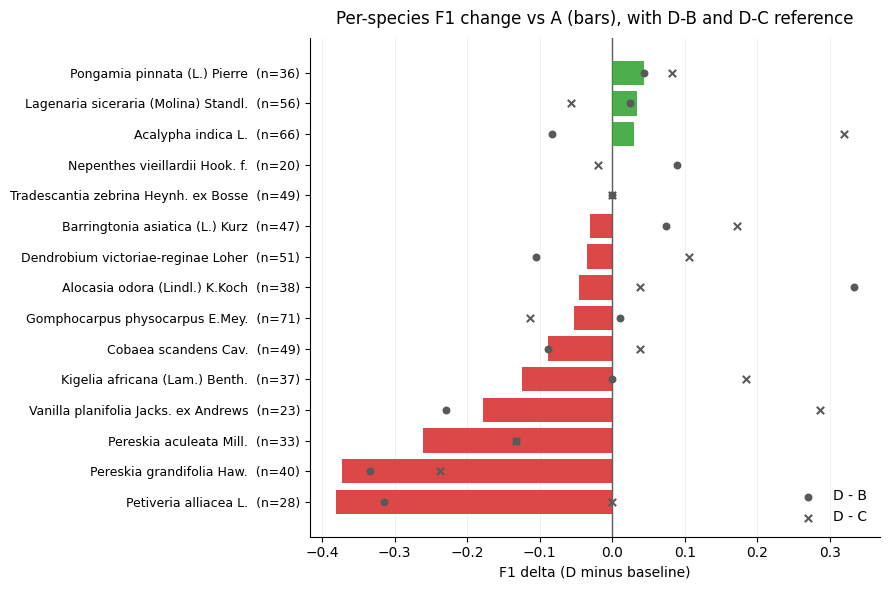

In [4]:
import matplotlib.pyplot as plt

d = merged.sort_values('d_vs_A')
y = np.arange(len(d))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in d.d_vs_A]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y, d.d_vs_A, color=colors, alpha=0.85, zorder=2)
ax.scatter(d.d_vs_B, y, color='0.35', marker='o', s=22, zorder=3, label='D - B')
ax.scatter(d.d_vs_C, y, color='0.35', marker='x', s=28, zorder=3, label='D - C')

ax.axvline(0, color='0.3', lw=1, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels([f'{n}  (n={t})' for n, t in zip(d.name, d.n_train)], fontsize=9)
ax.set_xlabel('F1 delta (D minus baseline)')
ax.set_title('Per-species F1 change vs A (bars), with D-B and D-C reference', fontsize=12, pad=10)
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.25, lw=0.5)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(NB05 / 'delta_per_species.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3) LoRA quality vs classifier error

เช็คว่า species ที่ D ทำพัง สัมพันธ์กับคุณภาพ LoRA ของตัวนั้นไหม 3 scatter เทียบ NB02 quality
(consistency / organ_acc) และ n_train กับ delta(D-A) พร้อม Pearson r highlight 2 ตัวที่ NB02 flag

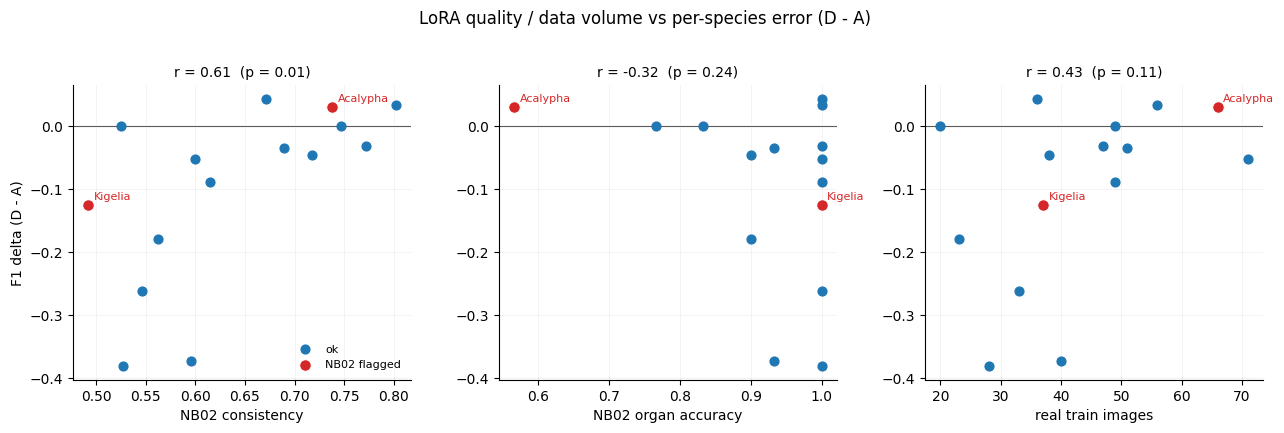

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

xvars = [('consistency', 'NB02 consistency'),
         ('organ_acc', 'NB02 organ accuracy'),
         ('n_train', 'real train images')]
flagged = merged.flag != 'ok'

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (col, label) in zip(axes, xvars):
    ax.scatter(merged.loc[~flagged, col], merged.loc[~flagged, 'd_vs_A'],
               color='#1f77b4', s=40, zorder=2, label='ok')
    ax.scatter(merged.loc[flagged, col], merged.loc[flagged, 'd_vs_A'],
               color='#d62728', s=70, zorder=3, edgecolor='white', linewidth=0.8, label='NB02 flagged')
    for _, r in merged[flagged].iterrows():
        ax.annotate(r['name'].split()[0], (r[col], r['d_vs_A']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points', color='#d62728')

    rho, p = pearsonr(merged[col], merged.d_vs_A)
    ax.axhline(0, color='0.3', lw=0.8, zorder=1)
    ax.set_xlabel(label)
    ax.set_title(f'r = {rho:.2f}  (p = {p:.2f})', fontsize=10)
    ax.grid(alpha=0.2, lw=0.5)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel('F1 delta (D - A)')
axes[0].legend(loc='lower right', frameon=False, fontsize=8)
fig.suptitle('LoRA quality / data volume vs per-species error (D - A)', fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig(NB05 / 'quality_vs_error_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### note: r และ p

r (Pearson) วัดว่าจุดเรียงเป็นเส้นตรงแค่ไหน อยู่ใน [-1, 1] บวกคือ X สูง Y สูงตาม
คิดจากส่วนต่างจากค่าเฉลี่ยของ x และ y คูณกันแล้วรวม หารด้วยการกระจายของทั้งสอง

p คือโอกาสที่จะสุ่มได้ r แรงเท่านี้ทั้งที่จริง x y ไม่เกี่ยวกัน p ต่ำ = น่าเชื่อ
เรามีแค่ 15 จุด p เลยอ่อน อ่าน r เป็นหลัก p แค่กันเคลมเกินตัว

In [6]:
x = merged.consistency.values
y = merged.d_vs_A.values

xc, yc = x - x.mean(), y - y.mean()
r_manual = (xc * yc).sum() / np.sqrt((xc**2).sum() * (yc**2).sum())

n = len(x)
t = r_manual * np.sqrt(n - 2) / np.sqrt(1 - r_manual**2)

print(f'r manual :\t{r_manual:.3f}')
print(f't stat   :\t{t:.3f}')
print(f'r scipy  :\t{pearsonr(x, y)[0]:.3f}')

r manual :	0.615
t stat   :	2.810
r scipy  :	0.615


In [7]:
from scipy import stats

n = len(x)
df = n - 2
p_manual = 2 * stats.t.sf(abs(t), df)

print(f't stat   :\t{t:.3f}')
print(f'df       :\t{df}')
print(f'p manual :\t{p_manual:.3f}')
print(f'p scipy  :\t{pearsonr(x, y)[1]:.3f}')

t stat   :	2.810
df       :	13
p manual :	0.015
p scipy  :	0.015


## Section 4) Confusion A vs D

ดูว่าเวลา rare ถูกทายผิด ไปลงเป็น species ไหน เทียบ A กับ D
rare->rare เช็คว่า rare สับกันเองไหม rare->common เช็คว่าถูกกลืนเป็น common ตัวไหน
ต้องโหลด ckpt A/D มา predict test เองเพราะ NB04 เก็บแค่ F1 ไม่ได้เก็บ prediction รายรูป

In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as TF
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50
from PIL import Image

DEVICE = 'cuda'
IMG_ROOT = ROOT / 'data' / 'raw' / 'plantnet_300K' / 'images'
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_tf = TF.Compose([
    TF.Resize((IMG_SIZE, IMG_SIZE)),
    TF.ToTensor(),
    TF.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

species_sorted = sorted(species_df.species_id.tolist())
sid_to_label = {sid: i for i, sid in enumerate(species_sorted)}
label_to_sid = {i: sid for sid, i in sid_to_label.items()}

test_df = splits_df[splits_df.split == 'test'].reset_index(drop=True)

class EvalDataset(Dataset):
    def __init__(self, df):
        self.paths = df.path.tolist()
        self.labels = [sid_to_label[s] for s in df.species_id]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(IMG_ROOT / self.paths[i]).convert('RGB')
        return eval_tf(img), self.labels[i]

def load_model(cond):
    ck = torch.load(NB04 / 'ckpt' / f'{cond}.pt', map_location=DEVICE)
    model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(sid_to_label))
    model.load_state_dict(ck['model'])
    return model.to(DEVICE).eval()

print(f'classes :\t{len(sid_to_label)}')
print(f'test    :\t{len(test_df):,} images')

classes :	399
test    :	35,986 images


In [12]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

@torch.no_grad()
def predict(model, dl):
    preds, trues = [], []
    for x, y in tqdm(dl, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            out = model(x)
        preds.append(out.argmax(1).cpu())
        trues.append(y)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()

test_dl = DataLoader(EvalDataset(test_df), batch_size=128, shuffle=False, num_workers=4)
rare_labels = [sid_to_label[s] for s in rare_ids]

pred = {}
for cond in ('A', 'D'):
    model = load_model(cond)
    pred[cond], y_true = predict(model, test_dl)
    del model
    torch.cuda.empty_cache()

for cond in ('A', 'D'):
    macro = f1_score(y_true, pred[cond], average='macro')
    rare = f1_score(y_true, pred[cond], labels=rare_labels, average='macro')
    print(f'{cond}  overall F1 :\t{macro:.4f}\t(NB04 {metrics[cond]["test_macro_f1"]:.4f})')
    print(f'{cond}  rare F1    :\t{rare:.4f}\t(NB04 {metrics[cond]["test_rare_f1"]:.4f})')

  0%|          | 0/282 [00:00<?, ?it/s]

  0%|          | 0/282 [00:00<?, ?it/s]

A  overall F1 :	0.6258	(NB04 0.6258)
A  rare F1    :	0.6438	(NB04 0.6438)
D  overall F1 :	0.6270	(NB04 0.6270)
D  rare F1    :	0.5463	(NB04 0.5463)


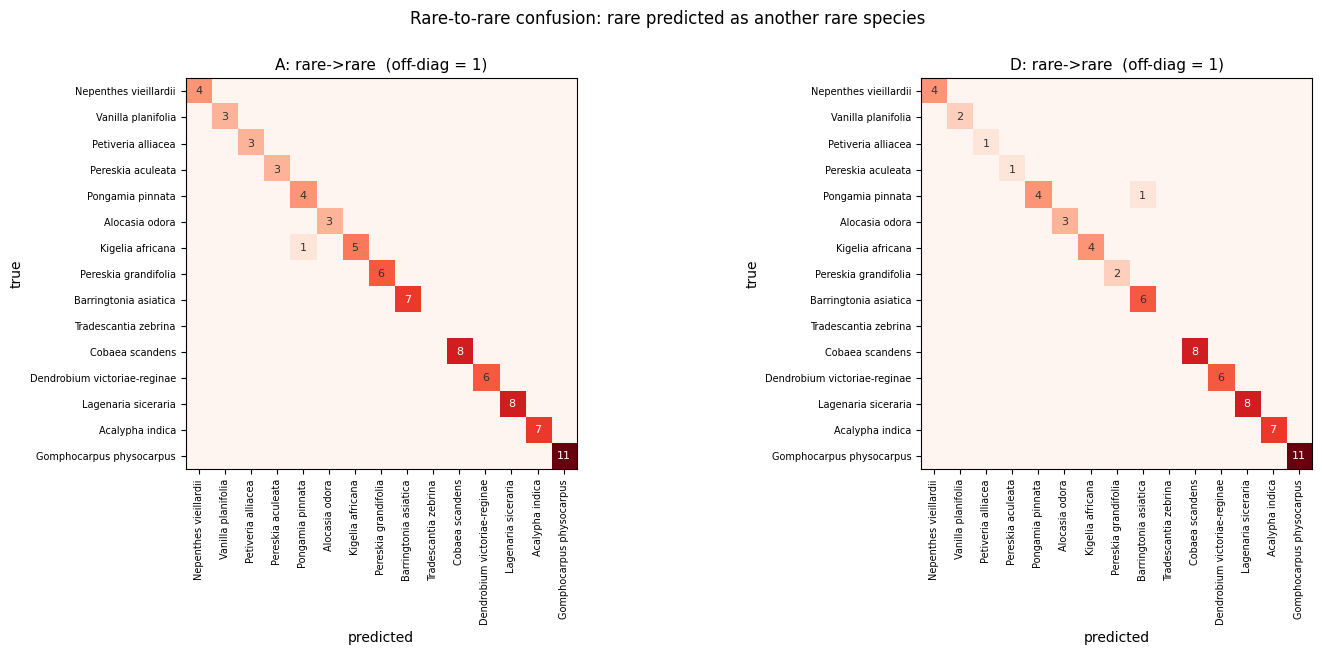

In [13]:
from sklearn.metrics import confusion_matrix

rare_names = [' '.join(name_map[s].split()[:2]) for s in rare_ids]
is_rare_true = np.isin(y_true, rare_labels)

def rare_to_rare_cm(yp):
    mask = is_rare_true & np.isin(yp, rare_labels)
    return confusion_matrix(y_true[mask], yp[mask], labels=rare_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, cond in zip(axes, ('A', 'D')):
    cm = rare_to_rare_cm(pred[cond])
    off = cm.copy()
    np.fill_diagonal(off, 0)
    ax.imshow(cm, cmap='Reds', vmin=0, vmax=cm.max())
    for i in range(15):
        for j in range(15):
            v = cm[i, j]
            if v > 0:
                ax.text(j, i, v, ha='center', va='center', fontsize=8,
                        color='white' if v > cm.max() * 0.6 else '0.2')
    ax.set_xticks(range(15)); ax.set_yticks(range(15))
    ax.set_xticklabels(rare_names, rotation=90, fontsize=7)
    ax.set_yticklabels(rare_names, fontsize=7)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{cond}: rare->rare  (off-diag = {off.sum()})', fontsize=11)

fig.suptitle('Rare-to-rare confusion: rare predicted as another rare species', fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig(NB05 / 'confusion_rare_AvsD.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
common_labels = [sid_to_label[s] for s in species_sorted if s not in set(rare_ids)]

def top_rare_to_common(yp, k=15):
    mask = is_rare_true & np.isin(yp, common_labels)
    rows = []
    for t, p in zip(y_true[mask], yp[mask]):
        rows.append((label_to_sid[t], label_to_sid[p]))
    return pd.Series(rows).value_counts().head(k)

records = []
for cond in ('A', 'D'):
    mask = is_rare_true & np.isin(pred[cond], common_labels)
    n_leak = int(mask.sum())
    print(f'{cond}  rare -> common :\t{n_leak}\t({n_leak / is_rare_true.sum() * 100:.1f}% ของ rare test)')

pairs = {}
for cond in ('A', 'D'):
    mask = is_rare_true & np.isin(pred[cond], common_labels)
    df = pd.DataFrame({
        'true_sid': [label_to_sid[t] for t in y_true[mask]],
        'pred_sid': [label_to_sid[p] for p in pred[cond][mask]],
    })
    g = df.groupby(['true_sid', 'pred_sid']).size().rename(f'{cond}_count')
    pairs[cond] = g

pair_df = pd.concat([pairs['A'], pairs['D']], axis=1).fillna(0).astype(int)
pair_df['delta'] = pair_df.D_count - pair_df.A_count
pair_df = pair_df.reset_index()
pair_df['true_name'] = pair_df.true_sid.map(name_map)
pair_df['pred_name'] = pair_df.pred_sid.map(name_map)
pair_df = pair_df.sort_values('delta', ascending=False)
pair_df.to_csv(NB05 / 'top_confused_pairs.csv', index=False)

print('\ntop rare->common pairs ที่ D เพิ่มจาก A')
print(pair_df[pair_df.delta > 0].head(10)[
    ['true_name', 'pred_name', 'A_count', 'D_count', 'delta']].to_string(index=False))

A  rare -> common :	56	(41.5% ของ rare test)
D  rare -> common :	67	(49.6% ของ rare test)

top rare->common pairs ที่ D เพิ่มจาก A
                     true_name                            pred_name  A_count  D_count  delta
Kigelia africana (Lam.) Benth.           Liriodendron tulipifera L.        0        2      2
     Pereskia grandifolia Haw. Anemone hupehensis (Lemoine) Lemoine        1        2      1
Kigelia africana (Lam.) Benth.                    Lactuca sativa L.        0        1      1
Kigelia africana (Lam.) Benth.          Pyracantha coccinea M.Roem.        0        1      1
            Acalypha indica L.                  Lapsana communis L.        0        1      1
          Cobaea scandens Cav.                 Aralia nudicaulis L.        0        1      1
     Pereskia grandifolia Haw.                Trifolium pratense L.        0        1      1
       Pereskia aculeata Mill. Zamioculcas zamiifolia (Lodd.) Engl.        0        1      1
       Pereskia aculeata Mill.  

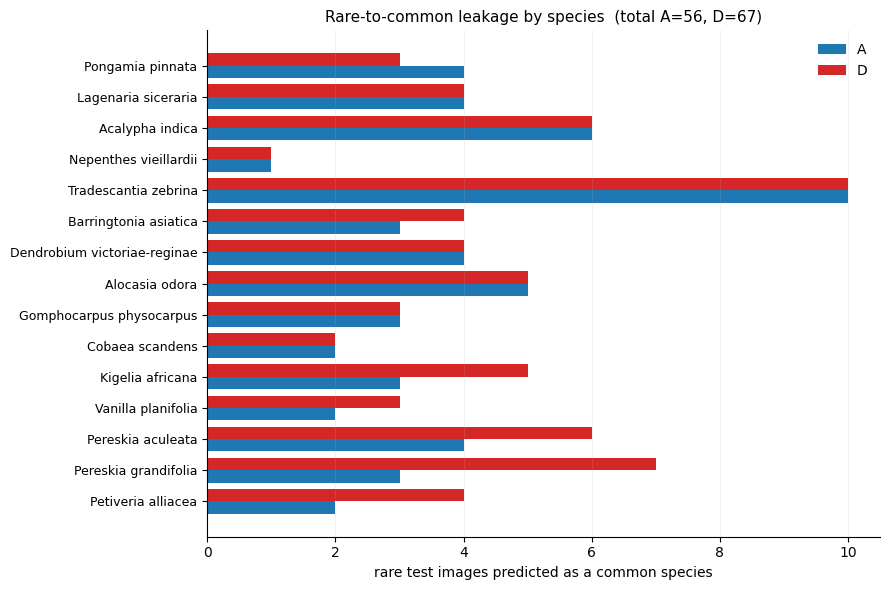

In [16]:
leak = {}
for cond in ('A', 'D'):
    mask = is_rare_true & np.isin(pred[cond], common_labels)
    s = pd.Series([label_to_sid[t] for t in y_true[mask]]).value_counts()
    leak[cond] = s.reindex(rare_ids, fill_value=0)

leak_df = pd.DataFrame(leak).loc[merged.sort_values('d_vs_A').species_id]
names = [' '.join(name_map[s].split()[:2]) for s in leak_df.index]
y = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y - 0.2, leak_df.A, height=0.4, color='#1f77b4', label='A')
ax.barh(y + 0.2, leak_df.D, height=0.4, color='#d62728', label='D')
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('rare test images predicted as a common species')
ax.set_title(f'Rare-to-common leakage by species  (total A={leak_df.A.sum()}, D={leak_df.D.sum()})', fontsize=11)
ax.legend(frameon=False)
ax.grid(axis='x', alpha=0.25, lw=0.5)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(NB05 / 'leak_rare_to_common.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5) Qualitative grid — 3 worst species

เปิดรูปจริงของ 3 species ที่ D พังหนักสุด (Petiveria, Pereskia grandifolia, Pereskia aculeata)
4 แถวต่อตัว real train / synthetic D / test ที่ A ถูก D ผิด / test ที่ทั้งคู่ผิด
ดูว่า synthetic หน้าตาต่างจาก real จน classifier เขวไหม

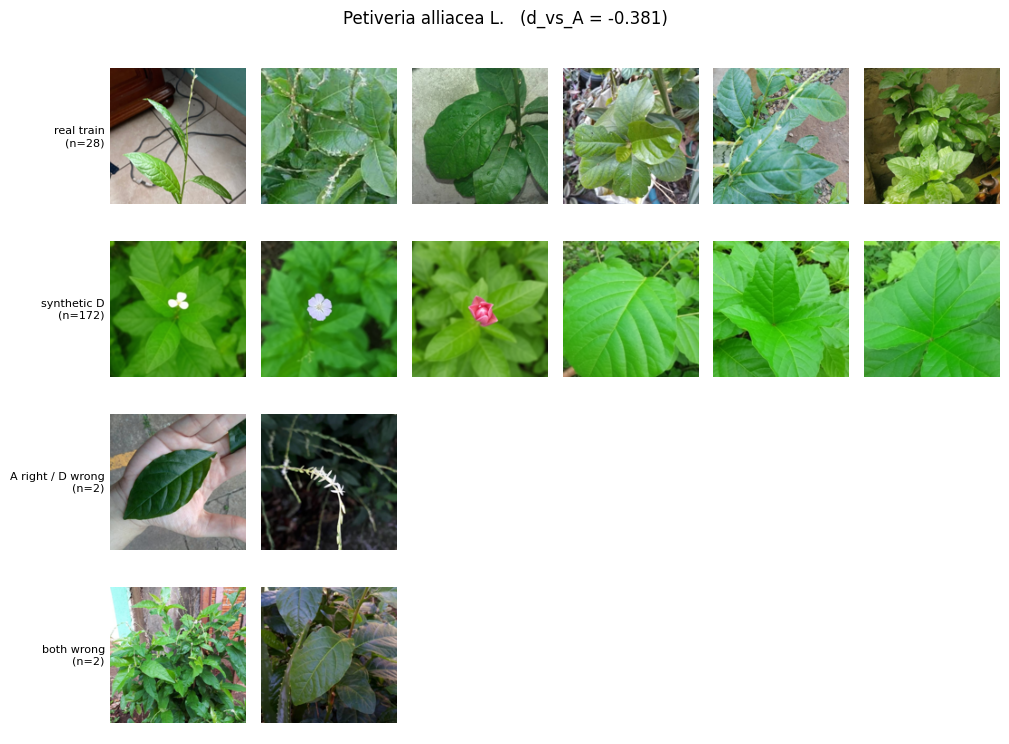

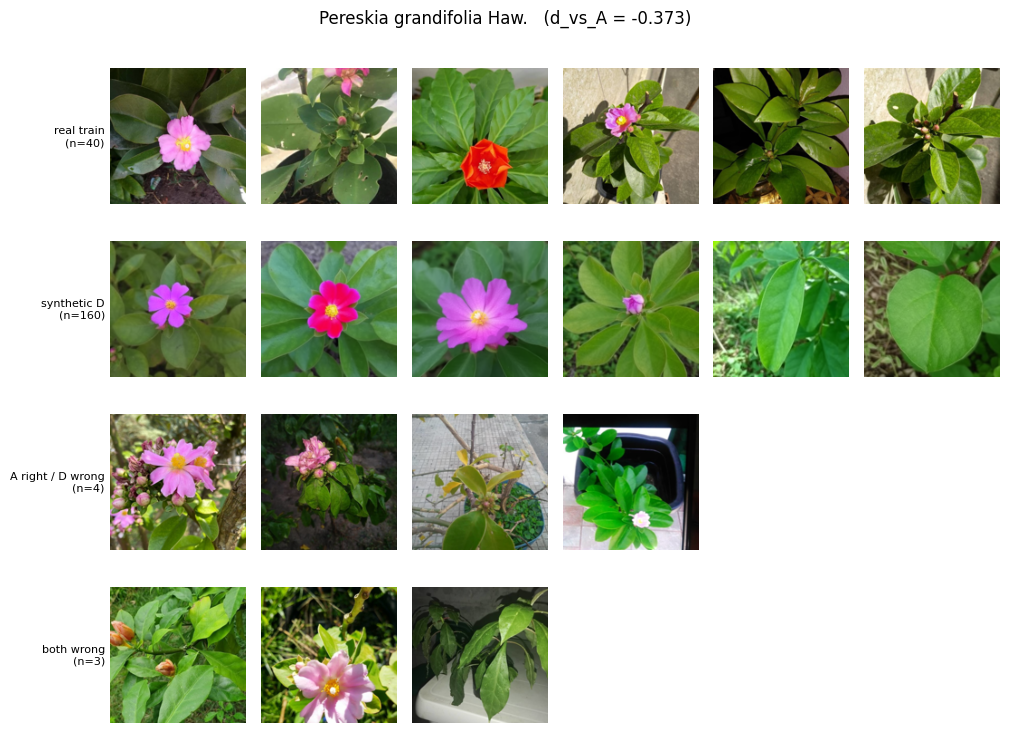

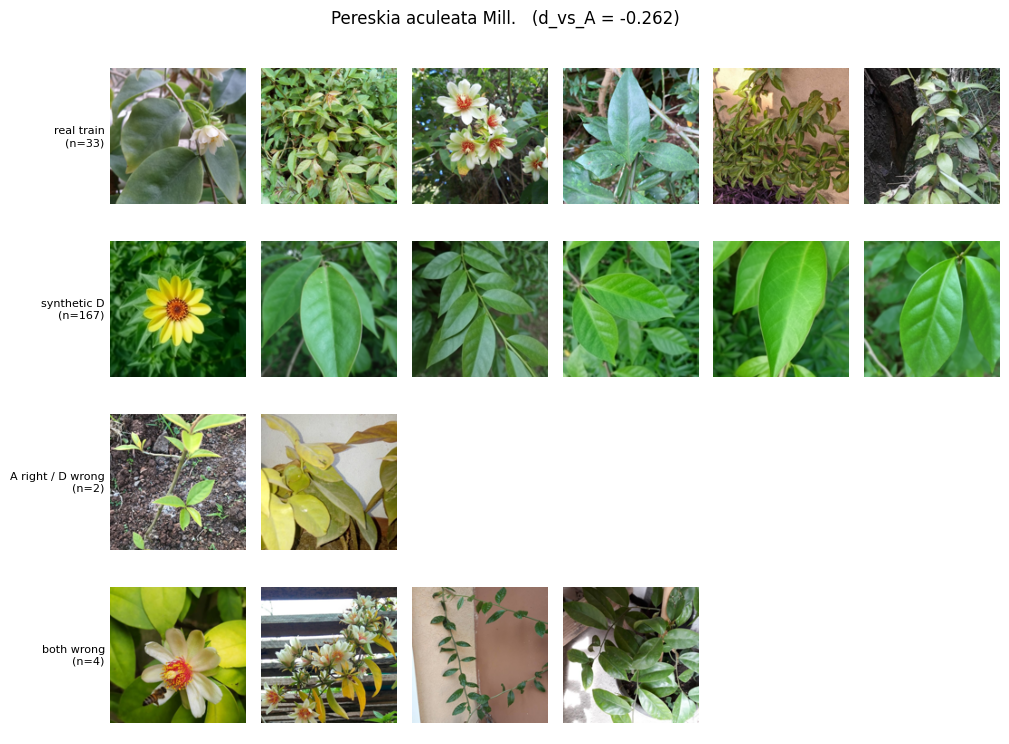

In [17]:
SYNTH_ROOT = ROOT / 'data' / 'synthetic'
COLS = 6
DISP = 150

man_d = manifest[manifest.source == 'lora_boost']
dva = merged.set_index('species_id').d_vs_A
worst3 = merged.head(3).species_id.tolist()

def disp_img(path):
    return np.asarray(Image.open(path).convert('RGB').resize((DISP, DISP)))

def pick(paths, k, seed):
    paths = list(paths)
    if not paths:
        return []
    rng = np.random.default_rng(seed)
    sel = rng.choice(len(paths), size=min(k, len(paths)), replace=False)
    return [paths[i] for i in sorted(sel)]

def species_rows(sid):
    lbl = sid_to_label[sid]
    train_p = [IMG_ROOT / p for p in
               splits_df[(splits_df.split == 'train') & (splits_df.species_id == sid)].path]
    synth_p = [SYNTH_ROOT / 'lora_boost' / p for p in man_d[man_d.species_id == sid].path]

    pos = np.where(test_df.species_id.values == sid)[0]
    a_ok, d_ok = pred['A'][pos] == lbl, pred['D'][pos] == lbl
    tp = test_df.path.values[pos]
    reg_p = [IMG_ROOT / p for p in tp[a_ok & ~d_ok]]
    both_p = [IMG_ROOT / p for p in tp[~a_ok & ~d_ok]]
    return [('real train', train_p), ('synthetic D', synth_p),
            ('A right / D wrong', reg_p), ('both wrong', both_p)]

for sid in worst3:
    rows = species_rows(sid)
    fig, axes = plt.subplots(4, COLS, figsize=(COLS * 1.7, 4 * 1.85))
    for r, (label, paths) in enumerate(rows):
        sel = pick(paths, COLS, seed=int(sid) + r)
        for c in range(COLS):
            ax = axes[r, c]
            if c < len(sel):
                ax.imshow(disp_img(sel[c]))
            if c == 0:
                ax.set_xticks([]); ax.set_yticks([])
                ax.set_ylabel(f'{label}\n(n={len(paths)})', rotation=0,
                              ha='right', va='center', fontsize=8)
                for s_ in ('top', 'right', 'bottom', 'left'):
                    ax.spines[s_].set_visible(False)
            else:
                ax.axis('off')
    fig.suptitle(f'{name_map[sid]}   (d_vs_A = {dva[sid]:.3f})', fontsize=12, y=1.0)
    plt.tight_layout()
    plt.savefig(NB05 / f'qualitative_{sid}.png', dpi=130, bbox_inches='tight')
    plt.show()

## Section 6) Summary

- **D ทำ rare แย่ลง 10/15 species** (mean d_vs_A = -0.097) ไม่ใช่ทุกตัวแต่กระจุกหนักที่
  Petiveria (-0.381), Pereskia grandifolia (-0.373), Pereskia aculeata (-0.262)

- **ไม่ใช่ hard-pair confusion** rare->rare แทบเป็น 0 ทั้ง A และ D Pereskia สองตัวไม่สับกันเอง
  (สีดอกต่างกัน ชมพู vs ขาว) สมมติฐาน hard pair ตั้งแต่ NB01 ตกไป

- **กลไกการพังคือ rare leak เป็น common** A 41.5% -> D 49.6% (+11 รูป) แบบกระจาย
  ไม่มี common ตัวไหนเป็นหลุมหลัก เพิ่มกระจุกที่ Pereskia คู่ + Kigelia + Petiveria

- **consistency (NB02) correlate กับ error จริง** r=0.61 p=0.015 LoRA ที่ consistency ต่ำ
  ทำ species แย่ลง organ_acc ไม่ correlate (r=-0.32 จุดเกาะ 1.0 พรืด) n_train อ่อน (r=0.43)

- **synthetic เพี้ยนเชิง semantic ไม่ใช่แค่คุณภาพ** LoRA บางตัว gen ผิด species หรือได้ใบเขียวเปล่า
  ที่ไม่มี discriminative feature ทำให้ classifier แยกจาก common ไม่ออก

  consistency (NB02)
  จับได้แค่บางส่วน ตัวที่ผิด species ชัดยังไม่ถูก flag (ยกเว้น Tradescantia F1=0 ทุก cond พังมาแต่ A)